In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from nn.nn import NeuralNetwork

## Load the digits dataset through sklearn using sklearn.datasets.load_digits()

In [8]:
X = load_digits().data 

print(f"dataset shape: {X.shape}")
print(f"number of samples: {X.shape[0]}")
print(f"number of features per sample: {X.shape[1]}")
print(f"pixel value range: [{X.min()}, {X.max()}]")

dataset shape: (1797, 64)
number of samples: 1797
number of features per sample: 64
pixel value range: [0.0, 16.0]


## Split the data into training and validation sets

In [11]:
# normalize pixel values from to [0, 1] so they match sigmoid 
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(f"Scaled pixel value range: [{X_scaled.min()}, {X_scaled.max()}]")

# 80% training 20% validation 
X_train, X_val = train_test_split(X_scaled, test_size=0.2, random_state=42)

y_train = X_train  # target = input (for an autoencoder, the target is the input)
y_val = X_val      # target = input

print(f"training set size:   {X_train.shape[0]} samples")
print(f"validation set size: {X_val.shape[0]} samples")

Scaled pixel value range: [0.0, 1.0]
training set size:   1437 samples
validation set size: 360 samples


## Generate an instance of your NeuralNetwork class with a 64x16x64 autoencoder architecture

In [14]:
# define the two layer architecture
# e.g. [{'input_dim': 64, 'output_dim': 16, 'activation': 'relu'}, {'input_dim': 16, 'output_dim': 64, 'activation:': 'sigmoid'}]

nn_arch = [
    {'input_dim': 64, 'output_dim': 16, 'activation': 'relu'},     # encoder
    {'input_dim': 16, 'output_dim': 64, 'activation': 'sigmoid'},   # decoder
]
# generate instance
autoencoder = NeuralNetwork(
    nn_arch=nn_arch,
    lr=0.1,                # learning rate  
    seed=42,                
    batch_size=64,          
    epochs=200,             
    loss_function='mse',     
)


## Train your autoencoder on the training data

In [15]:
print("Training autoencoder...")
train_losses, val_losses = autoencoder.fit(X_train, y_train, X_val, y_val)
print(f"Training complete!")
print(f"Final training loss:   {train_losses[-1]:.6f}")
print(f"Final validation loss: {val_losses[-1]:.6f}")

Training autoencoder...
Training complete!
Final training loss:   3.592318
Final validation loss: 3.571302
Training complete!
Final training loss:   3.592318
Final validation loss: 3.571302


## Plot your training and validation loss by epoch

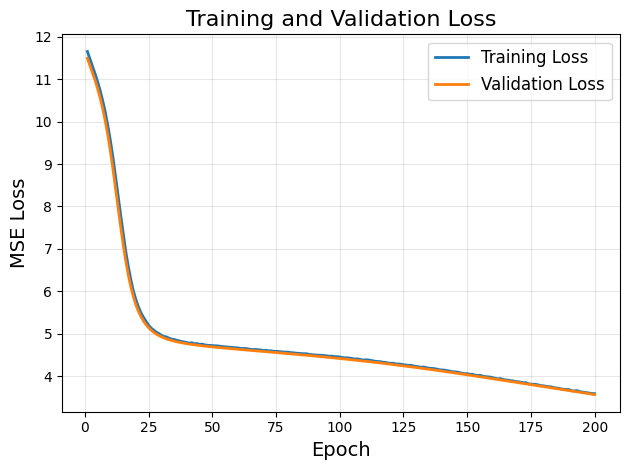

In [24]:
plt.figure()
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss', linewidth=2)
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('MSE Loss', fontsize=14)
plt.title('Training and Validation Loss', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Quantify your average reconstruction error over the validation set
$$\text{Reconstruction Error} = \frac{1}{n} \sum_{i=1}^{n} \| \mathbf{x}_i - \hat{\mathbf{x}}_i \|^2$$

also visualize a few original vs reconstructed digit images to qualitatively assess reconstruction quality

In [ ]:
# get reconstructions for the validation set
X_val_reconstructed = autoencoder.predict(X_val).T

# average MSE reconstruction error
per_sample_mse = np.mean((X_val - X_val_reconstructed) ** 2, axis=1)
avg_reconstruction_error = np.mean(per_sample_mse)

print(f"Average reconstruction error (MSE) on validation set: {avg_reconstruction_error:.6f}")
print(f"Min per-sample error:  {per_sample_mse.min():.6f}")
print(f"Max per-sample error:  {per_sample_mse.max():.6f}")

Average reconstruction error (MSE) on validation set: 0.055802
Min per-sample error:  0.028744
Max per-sample error:  0.125588


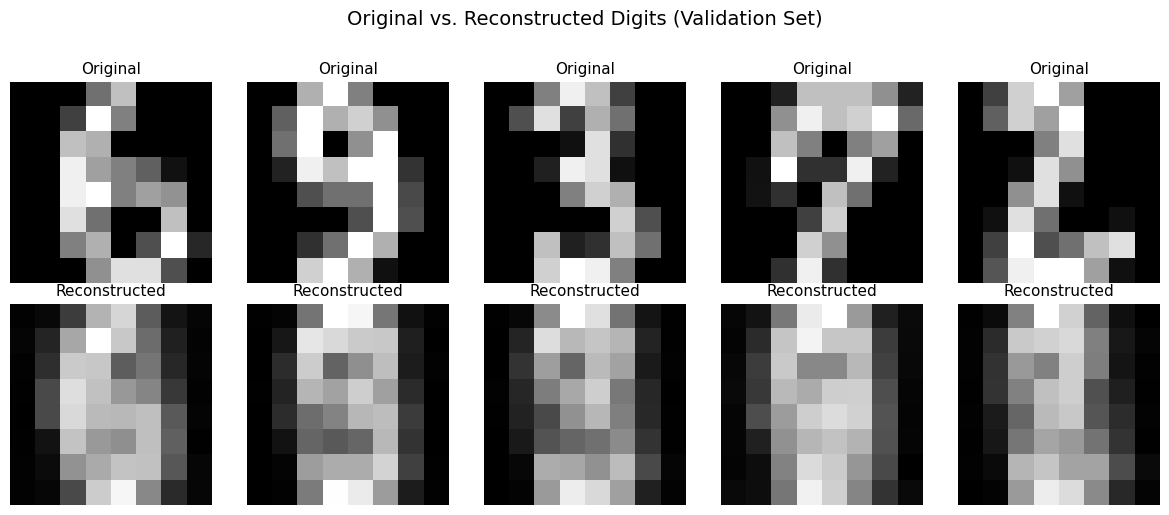

In [ ]:
# look at 5 original vs reconstructed digit images 
n_display = 5
fig, axes = plt.subplots(2, n_display, figsize=(12, 5))

for i in range(n_display):
    # Original image, top row
    axes[0, i].imshow(X_val[i].reshape(8, 8), cmap='gray')
    axes[0, i].set_title('Original', fontsize=11)
    axes[0, i].axis('off')

    # Reconstructed image, bottom row
    axes[1, i].imshow(X_val_reconstructed[i].reshape(8, 8), cmap='gray')
    axes[1, i].set_title('Reconstructed', fontsize=11)
    axes[1, i].axis('off')

plt.suptitle('Original vs. Reconstructed Digits (Validation Set)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## make sure no data leak

In [25]:
# do train and val share any memory?  
print("X_train and X_val share memory?", np.shares_memory(X_train, X_val))
print("y_train is X_train?", y_train is X_train)
print("y_val is X_val?", y_val is X_val)

# are any validation rows present in the training set?
overlap_count = 0
for row in X_val:
    if any(np.allclose(row, train_row) for train_row in X_train):
        overlap_count += 1
print(f"\nOverlapping samples between train and val: {overlap_count} / {len(X_val)}")

# train vs val loss 
print(f"\nTrain loss (final epoch): {train_losses[-1]:.6f}")
print(f"Val loss (final epoch):   {val_losses[-1]:.6f}")
print(f"Difference:               {abs(train_losses[-1] - val_losses[-1]):.6f}")

# dataset sizes
print(f"\nTrain size: {X_train.shape[0]}, Val size: {X_val.shape[0]}, Total: {X_train.shape[0] + X_val.shape[0]}")

X_train and X_val share memory? False
y_train is X_train? True
y_val is X_val? True

Overlapping samples between train and val: 0 / 360

Train loss (final epoch): 3.592318
Val loss (final epoch):   3.571302
Difference:               0.021016

Train size: 1437, Val size: 360, Total: 1797

Overlapping samples between train and val: 0 / 360

Train loss (final epoch): 3.592318
Val loss (final epoch):   3.571302
Difference:               0.021016

Train size: 1437, Val size: 360, Total: 1797


## Hyperparameter Justification

| Hyperparameter | Value | Reasoning |
|---|---|---|
| **Learning rate** | `0.1` | A moderately high learning rate allows fast convergence on this small dataset (1,797 samples). The digits data is relatively simple and well-structured, so larger steps don't overshoot the optimum. A lower rate like 0.001 would converge too slowly; much higher (e.g., 1.0) would cause instability. |
| **Batch size** | `64` | A batch size of 64 strikes a balance between gradient stability and training speed. Smaller batches (e.g., 8) introduce more noise in gradient estimates; larger batches (e.g., 512) would cover nearly the whole training set in one step, reducing the benefit of stochastic updates. |
| **Epochs** | `200` | 200 epochs provides enough training iterations for the loss to converge and plateau. The validation loss curve can be monitored for signs of overfitting — if it starts rising while training loss continues falling, we would stop earlier. |
| **Loss function** | `mse` | Mean squared error is the standard choice for reconstruction tasks. It directly penalizes pixel-wise deviation between the input and its reconstruction, making it a natural fit for autoencoders. |
| **Hidden activation (ReLU)** | `relu` | ReLU introduces non-linearity in the encoder while avoiding the vanishing gradient problem that affects sigmoid in hidden layers. It also naturally produces sparse representations (many zeros), which is a desirable property for encodings. |
| **Output activation (Sigmoid)** | `sigmoid` | Since we normalized the input data to [0, 1], the output layer must also produce values in [0, 1]. Sigmoid maps any real number to this range, making it the appropriate choice for the decoder's output activation. |